Chrombpnet-scE2G Overlap

Overlap modisco pattern peaks (TF binding sites from ChromBPNet) with scE2G enhancer–gene links to produce a TF → Enhancer → Gene regulatory network

**to make this version better, use the TSS for mapping (but will be much more stringent)

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from ncls import NCLS

BASE        = Path("/Users/sidharthraghavan/Library/CloudStorage/OneDrive-Personal/Sid_stuff/PROJECTS/tf_perturb_seq/grn_analysis")
E2G_TSV     = BASE / "datasets/scE2G/igvf3_wtc11_cardio_cardiomyocyte_scE2G_multiome_powerlaw_v3_threshold0.177.e2g.tsv"
PATTERN_DIR = BASE / "datasets/chrombp_net"
N_PATTERNS  = 7
OUT_DIR     = BASE / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print("E2G file exists:", E2G_TSV.exists())

E2G file exists: True


In [11]:
# Load scE2G
e2g = pd.read_csv(E2G_TSV, sep='\t', comment='#')
print(f"Unique enhancers : {e2g['ElementName'].nunique():,}")
print(f"Unique genes     : {e2g['GeneSymbol'].nunique():,}")
print(f"Total E→G links  : {len(e2g):,}")
e2g.head()

Unique enhancers : 45,170
Unique genes     : 11,852
Total E→G links  : 55,643


,ElementChr,ElementStart,ElementEnd,ElementName,ElementClass,GeneSymbol,GeneEnsemblID,GeneTSS,SampleSummaryShort,Score,Score.ignoreTPM,isSelfPromoter
0,chr1,778181,778964,chr1:778181-778964,intergenic,LINC01128,ENSG00000228794,827590,wtc11_cardio_cardiomyocyte,0.179209,0.179209,False
1,chr1,826516,827016,chr1:826516-827016,genic,LINC00115,ENSG00000225880,827522,wtc11_cardio_cardiomyocyte,0.264953,0.264953,False
2,chr1,826516,827016,chr1:826516-827016,genic,LINC01128,ENSG00000228794,827590,wtc11_cardio_cardiomyocyte,0.286776,0.286776,False
3,chr1,827272,827840,chr1:827272-827840,promoter,LINC00115,ENSG00000225880,827522,wtc11_cardio_cardiomyocyte,0.977320,0.977320,True
4,chr1,827272,827840,chr1:827272-827840,promoter,LINC01128,ENSG00000228794,827590,wtc11_cardio_cardiomyocyte,0.975716,0.975716,True


In [12]:
# load bed files
BED_COLS = ['Chromosome', 'Start', 'End', 'peak_name', 'score', 'strand',
            'signalValue', 'pValue', 'qValue', 'peak_offset']

dfs = []
for i in range(N_PATTERNS):
    df = pd.read_csv(PATTERN_DIR / f"pattern_{i}_peaks.bed",
                     sep='\t', header=None, names=BED_COLS)
    df['pattern_id'] = i
    dfs.append(df)

patterns_all = pd.concat(dfs, ignore_index=True)
print(f"Total pattern peaks: {len(patterns_all):,}")
patterns_all.groupby('pattern_id').size().rename('n_peaks').to_frame()

Total pattern peaks: 119,487


,n_peaks
pattern_id,
0,27805
1,23126
2,17027
3,14641
4,12663
5,12305
6,11920


In [13]:
# Parse TF names from motifs.html
# pos_patterns only — neg_patterns share the same IDs and must be excluded
# match0 = best hit; TF gene symbol = everything before the first underscore

MOTIFS_HTML = PATTERN_DIR / "motifs.html"

motifs_df = pd.read_html(str(MOTIFS_HTML))[0]
motifs_df = motifs_df[motifs_df["pattern"].str.startswith("pos_patterns")].copy()
motifs_df["pattern_id"] = motifs_df["pattern"].str.extract(r"pattern_(\d+)").astype(int)
motifs_df["TF_name"]    = motifs_df["match0"].str.split("_").str[0]
motifs_df = motifs_df[motifs_df["pattern_id"] < N_PATTERNS].reset_index(drop=True)

pattern_tf_map = motifs_df.set_index("pattern_id")["TF_name"].to_dict()
patterns_all["TF_name"] = patterns_all["pattern_id"].map(pattern_tf_map)

motifs_df[["pattern_id", "TF_name", "match0", "qval0", "match1", "qval1", "match2", "qval2"]]

,pattern_id,TF_name,match0,qval0,match1,qval1,match2,qval2
0,0,CTCF,CTCF_MA0139.1,3.986050e-17,CTCF_HUMAN.H11MO.0.A,1.058950e-15,CTCF_MOUSE.H11MO.0.A,1.229930e-12
1,1,TEAD1,TEAD1_HUMAN.H11MO.0.A,1.382090e-04,TEAD4_HUMAN.H11MO.0.A,1.382090e-04,TEAD3_MA0808.1,2.058590e-04
2,2,TBX20,TBX20_MOUSE.H11MO.0.C,1.997430e-05,MEIS1_MA0498.2,4.222660e-02,MEIS1_MEIS_1,4.222660e-02
3,3,HAND1,HAND1_MOUSE.H11MO.0.C,3.465340e-04,TWST1_HUMAN.H11MO.0.A,1.000000e+00,TWST1_MOUSE.H11MO.0.B,1.000000e+00
4,4,KLF12,KLF12_HUMAN.H11MO.0.C,3.915230e-06,SP3_HUMAN.H11MO.0.B,3.915230e-06,SP3_MOUSE.H11MO.0.B,3.915230e-06
5,5,NKX2-3,NKX2-3_MA0672.1,1.274840e-06,NKX2-3_homeodomain_2,1.274840e-06,NKX2-8_homeodomain_1,7.045570e-06
6,6,GATA4,GATA4_HUMAN.H11MO.0.A,1.273760e-02,GATA4_MOUSE.H11MO.0.A,1.273760e-02,GATA6_MOUSE.H11MO.0.A,1.273760e-02


if a pattern peak window [Start, End) overlaps an scE2G element window [ElementStart, ElementEnd) on the same chromosome, than that TF binds that enhancer.

In [14]:
def overlap_patterns_with_elements(patterns_df, elements_df):
    """
    Chromosome-by-chromosome interval overlap using NCLS.
    Returns one row per (pattern peak, overlapping scE2G element).
    """
    unique_elems = (elements_df[['ElementChr', 'ElementStart', 'ElementEnd', 'ElementName']]
                    .drop_duplicates('ElementName')
                    .reset_index(drop=True))

    records = []
    for chrom in tqdm(sorted(patterns_df['Chromosome'].unique()), desc='chromosomes'):
        pat   = patterns_df[patterns_df['Chromosome'] == chrom].reset_index(drop=True)
        elems = unique_elems[unique_elems['ElementChr'] == chrom].reset_index(drop=True)
        if len(elems) == 0:
            continue

        tree = NCLS(
            elems['ElementStart'].values.astype(np.int64),
            elems['ElementEnd'].values.astype(np.int64),
            elems.index.values.astype(np.int64),
        )

        for _, row in pat.iterrows():
            for _, _, elem_idx in tree.find_overlap(int(row['Start']), int(row['End'])):
                records.append({
                    'pattern_id'  : row['pattern_id'],
                    'TF_name'     : row['TF_name'],
                    'peak_chr'    : chrom,
                    'peak_start'  : int(row['Start']),
                    'peak_end'    : int(row['End']),
                    'peak_summit' : int(row['Start']) + int(row['peak_offset']),
                    'signalValue' : row['signalValue'],
                    'ElementName' : elems.loc[elem_idx, 'ElementName'],
                })

    return pd.DataFrame(records)


tf_enh_raw = overlap_patterns_with_elements(patterns_all, e2g)
print(f"Raw overlaps: {len(tf_enh_raw):,}")

chromosomes:   0%|          | 0/42 [00:00<?, ?it/s]

Raw overlaps: 38,569


Join with scE2G to get target genes, then deduplicate to **one row per (TF, enhancer, gene)** keeping the highest `signalValue` binding event.

In [15]:
e2g_cols = ['ElementName', 'ElementChr', 'ElementStart', 'ElementEnd',
            'ElementClass', 'GeneSymbol', 'GeneEnsemblID', 'Score', 'isSelfPromoter']

tf_enh_gene = (
    tf_enh_raw
    .merge(e2g[e2g_cols].drop_duplicates(['ElementName', 'GeneSymbol']),
           on='ElementName', how='left')
    .sort_values('signalValue', ascending=False)
    .drop_duplicates(subset=['pattern_id', 'ElementName', 'GeneSymbol'])
    .sort_values(['pattern_id', 'peak_chr', 'peak_start'])
    .reset_index(drop=True)
)

print(f"Final TF → Enhancer → Gene table: {len(tf_enh_gene):,} rows")
print(f"Unique TF patterns   : {tf_enh_gene['pattern_id'].nunique()}")
print(f"Unique enhancers     : {tf_enh_gene['ElementName'].nunique():,}")
print(f"Unique genes reached : {tf_enh_gene['GeneSymbol'].nunique():,}")
tf_enh_gene.head(10)

Final TF → Enhancer → Gene table: 31,978 rows
Unique TF patterns   : 7
Unique enhancers     : 19,004
Unique genes reached : 8,870


,pattern_id,TF_name,peak_chr,peak_start,peak_end,peak_summit,signalValue,ElementName,ElementChr,ElementStart,ElementEnd,ElementClass,GeneSymbol,GeneEnsemblID,Score,isSelfPromoter
0,0,CTCF,chr1,869671,870180,869821,7.62332,chr1:869694-870419,chr1,869694,870419,genic,LINC01128,ENSG00000228794,0.178453,False
1,0,CTCF,chr1,869671,870180,869821,7.62332,chr1:869694-870419,chr1,869694,870419,genic,LINC00115,ENSG00000225880,0.194559,False
2,0,CTCF,chr1,904506,905056,904850,5.20231,chr1:904165-905013,chr1,904165,905013,intergenic,SAMD11,ENSG00000187634,0.521250,False
3,0,CTCF,chr1,920962,921469,921123,6.12813,chr1:921020-921520,chr1,921020,921520,intergenic,NOC2L,ENSG00000188976,0.227170,False
4,0,CTCF,chr1,920962,921469,921123,6.12813,chr1:921020-921520,chr1,921020,921520,intergenic,KLHL17,ENSG00000187961,0.200980,False
5,0,CTCF,chr1,920962,921469,921123,6.12813,chr1:921020-921520,chr1,921020,921520,intergenic,SAMD11,ENSG00000187634,0.913232,False
6,0,CTCF,chr1,938068,938509,938406,4.16141,chr1:938038-938538,chr1,938038,938538,genic,SAMD11,ENSG00000187634,0.327602,False
7,0,CTCF,chr1,938068,938509,938406,4.16141,chr1:938038-938538,chr1,938038,938538,genic,NOC2L,ENSG00000188976,0.284403,False
8,0,CTCF,chr1,1032443,1033462,1033307,9.34112,chr1:1032407-1033379,chr1,1032407,1033379,genic,ISG15,ENSG00000187608,0.431935,False
9,0,CTCF,chr1,1032443,1033462,1033307,9.34112,chr1:1032407-1033379,chr1,1032407,1033379,genic,AGRN,ENSG00000188157,0.646536,False


In [20]:
# count unique TF - gene pairs
total_pairs = unique_tf_gene.drop_duplicates(['TF_name', 'GeneSymbol']).shape[0]
print(f"Total unique TF–gene pairs: {total_pairs:,}")

# per-TF unique gene counts
tf_gene_counts = unique_tf_gene.groupby('TF_name')['GeneSymbol'].nunique().sort_values(ascending=False)
print("\nUnique genes per TF:")
print(tf_gene_counts)

Total unique TF–gene pairs: 20,619

Unique genes per TF:
TF_name
KLF12     5661
CTCF      5124
TEAD1     2921
TBX20     1932
HAND1     1763
GATA4     1746
NKX2-3    1472
Name: GeneSymbol, dtype: int64


In [16]:
# Per-pattern summary: enhancers and genes reached by each TF motif
summary = (
    tf_enh_gene
    .groupby(['pattern_id', 'TF_name'])
    .agg(n_enhancers=('ElementName', 'nunique'),
         n_genes    =('GeneSymbol',  'nunique'),
         mean_signal=('signalValue', 'mean'),
         mean_e2g   =('Score',       'mean'))
    .reset_index()
    .sort_values('n_genes', ascending=False)
)
summary

,pattern_id,TF_name,n_enhancers,n_genes,mean_signal,mean_e2g
4,4,KLF12,6058,5661,8.874937,0.717409
0,0,CTCF,7114,5124,6.790642,0.495193
1,1,TEAD1,3834,2921,7.213937,0.399925
2,2,TBX20,2283,1932,7.787184,0.386500
3,3,HAND1,2061,1763,7.799915,0.384650
6,6,GATA4,1959,1746,7.450687,0.377086
5,5,NKX2-3,1576,1472,7.583089,0.379148


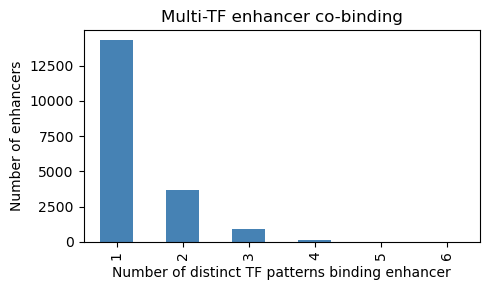

Enhancers bound by ≥2 patterns: 4,719 / 19,004


In [17]:
# How many distinct TF patterns co-bind each enhancer?
patterns_per_enh = tf_enh_gene.groupby('ElementName')['pattern_id'].nunique()

fig, ax = plt.subplots(figsize=(5, 3))
patterns_per_enh.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Number of distinct TF patterns binding enhancer')
ax.set_ylabel('Number of enhancers')
ax.set_title('Multi-TF enhancer co-binding')
plt.tight_layout()
plt.show()
print(f"Enhancers bound by ≥2 patterns: {(patterns_per_enh >= 2).sum():,} / {len(patterns_per_enh):,}")

| Column | Meaning |
|---|---|
| `pattern_id` | Modisco pattern index (0–6) |
| `TF_name` | TF name — fill in `PATTERN_TF_MAP` after checking `motifs.html` |
| `peak_chr/start/end` | Genomic window where TF motif was found |
| `peak_summit` | Highest-confidence binding base within the window |
| `signalValue` | Modisco binding strength |
| `ElementName/Chr/Start/End` | scE2G enhancer coordinates |
| `ElementClass` | intergenic / genic / promoter |
| `GeneSymbol`, `GeneEnsemblID` | Target gene |
| `Score` | scE2G E→G link strength |
| `isSelfPromoter` | Whether element is the gene's own promoter |

In [18]:
OUT_GRN = OUT_DIR / "TF_enhancer_gene_grn.tsv"
tf_enh_gene.to_csv(OUT_GRN, sep='\t', index=False)